## import the needed library


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from soupsieve.util import lower

In [2]:
weather = pd.read_csv(r'weatherHistory.csv')

In [3]:
weather

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [4]:
weather.describe()

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
count,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.000000,96453.0,96453.000000
mean,11.932678,10.855029,0.734899,10.810640,187.509232,10.347325,0.0,1003.235956
std,9.551546,10.696847,0.195473,6.913571,107.383428,4.192123,0.0,116.969906
min,-21.822222,-27.716667,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,4.688889,2.311111,0.600000,5.828200,116.000000,8.339800,0.0,1011.900000
50%,12.000000,12.000000,0.780000,9.965900,180.000000,10.046400,0.0,1016.450000
75%,18.838889,18.838889,0.890000,14.135800,290.000000,14.812000,0.0,1021.090000
max,39.905556,39.344444,1.000000,63.852600,359.000000,16.100000,0.0,1046.380000


In [5]:
weather.isna().sum()

Formatted Date                0
Summary                       0
Precip Type                 517
Temperature (C)               0
Apparent Temperature (C)      0
Humidity                      0
Wind Speed (km/h)             0
Wind Bearing (degrees)        0
Visibility (km)               0
Loud Cover                    0
Pressure (millibars)          0
Daily Summary                 0
dtype: int64

In [6]:
weather.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

In [7]:
weather['Precip Type'].isna().sum()

np.int64(517)

In [8]:
weather['Precip Type'].unique()

array(['rain', 'snow', nan], dtype=object)

In [9]:
weather['Precip Type'].describe()

count     95936
unique        2
top        rain
freq      85224
Name: Precip Type, dtype: object

In [10]:
weather['Precip Type'] = weather['Precip Type'].fillna("rain")

In [11]:
weather['Precip Type'].isna().sum()

np.int64(0)

In [12]:
weather.duplicated().sum()

np.int64(24)

In [13]:
weather = weather.drop_duplicates()

In [14]:
weather.duplicated().sum()

np.int64(0)

In [15]:
weather.head()

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.


In [16]:
weather.columns

Index(['Formatted Date', 'Summary', 'Precip Type', 'Temperature (C)',
       'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)',
       'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover',
       'Pressure (millibars)', 'Daily Summary'],
      dtype='object')

###### checking the loud cover column to confirm the values if its affecting the weather or not.

In [17]:
weather['Loud Cover'].unique()

array([0.])

In [18]:
weather['Daily Summary'].nunique()

214

In [19]:
weather['Summary'].nunique()

27

In [20]:
weather['Formatted Date'] = pd.to_datetime(weather['Formatted Date'], utc = True, errors = 'coerce')

C:\Users\USER\AppData\Local\Temp\ipykernel_6212\418374035.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather['Formatted Date'] = pd.to_datetime(weather['Formatted Date'], utc = True, errors = 'coerce')


#### Extracting year, month , day and hour

In [21]:
weather['year'] = weather['Formatted Date'].dt.year
weather['month'] = weather['Formatted Date'].dt.month
weather['day'] = weather['Formatted Date'].dt.day
weather['hour'] = weather['Formatted Date'].dt.hour

C:\Users\USER\AppData\Local\Temp\ipykernel_6212\2777632156.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather['year'] = weather['Formatted Date'].dt.year
C:\Users\USER\AppData\Local\Temp\ipykernel_6212\2777632156.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  weather['month'] = weather['Formatted Date'].dt.month
C:\Users\USER\AppData\Local\Temp\ipykernel_6212\2777632156.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [22]:
weather = weather.drop(columns = ['Formatted Date','Formatted Date'])

In [23]:
weather = weather.drop(columns = ['Loud Cover','Daily Summary'])

In [24]:
weather.dtypes

Summary                      object
Precip Type                  object
Temperature (C)             float64
Apparent Temperature (C)    float64
Humidity                    float64
Wind Speed (km/h)           float64
Wind Bearing (degrees)      float64
Visibility (km)             float64
Pressure (millibars)        float64
year                          int32
month                         int32
day                           int32
hour                          int32
dtype: object

## To check for outliners in column windspeed

{'whiskers': [<matplotlib.lines.Line2D at 0x184fb621590>,
 'caps': [<matplotlib.lines.Line2D at 0x184fb621810>,
 'boxes': [<matplotlib.lines.Line2D at 0x184fb3c9450>],
 'medians': [<matplotlib.lines.Line2D at 0x184fb621a90>],
 'fliers': [<matplotlib.lines.Line2D at 0x184fb621bd0>],
 'means': []}

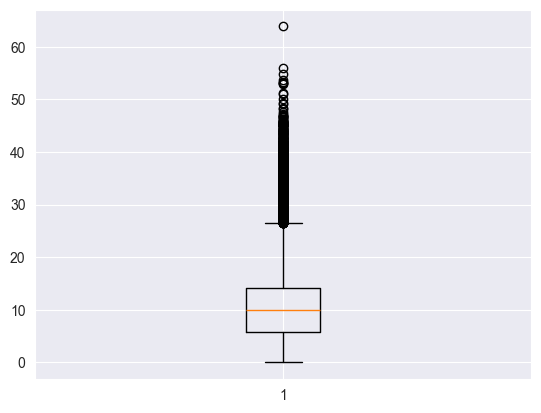

In [25]:
plt.boxplot(weather['Wind Speed (km/h)'])

In [39]:
weather['Wind Speed (km/h)'].unique()

array([14.1197, 14.2646,  3.9284, ..., 37.0622, 35.5971, 30.751 ],
      shape=(2484,))

In [26]:
print(weather)

             Summary Precip Type  Temperature (C)  Apparent Temperature (C)  \
0      Partly Cloudy        rain         9.472222                  7.388889   
1      Partly Cloudy        rain         9.355556                  7.227778   
2      Mostly Cloudy        rain         9.377778                  9.377778   
3      Partly Cloudy        rain         8.288889                  5.944444   
4      Mostly Cloudy        rain         8.755556                  6.977778   
...              ...         ...              ...                       ...   
96448  Partly Cloudy        rain        26.016667                 26.016667   
96449  Partly Cloudy        rain        24.583333                 24.583333   
96450  Partly Cloudy        rain        22.038889                 22.038889   
96451  Partly Cloudy        rain        21.522222                 21.522222   
96452  Partly Cloudy        rain        20.438889                 20.438889   

       Humidity  Wind Speed (km/h)  Wind Bearing (d

##### * Solving Outliners*

In [27]:
# Q1 = weather['Wind Speed (km/h)'].quantile(0.25)
# Q3 = weather['Wind Speed (km/h)'].quantile(0.75)
# IQR = Q3 - Q1
# lower_bound = Q1 - 1.5 * IQR
# upper_bound = Q3 + 1.5 * IQR

###### Am ignoring the outliner cause it also has an effect at 63 which is the highest and also the lowest

In [41]:
weather

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),year,month,day,hour
0,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,2006,3,31,22
1,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,2006,3,31,23
2,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,2006,4,1,0
3,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,2006,4,1,1
4,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,2006,4,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96448,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,1014.36,2016,9,9,17
96449,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,1015.16,2016,9,9,18
96450,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,1015.66,2016,9,9,19
96451,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,1015.95,2016,9,9,20


###### ill be converting the preciptype to numbers 1 for rain 0 for snow

In [44]:
weather['Precip Type'].replace('rain', 1, inplace = True)
weather['Precip Type'].replace('snow', 0, inplace = True)

C:\Users\USER\AppData\Local\Temp\ipykernel_6212\3754746511.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  weather['Precip Type'].replace('rain', 1, inplace = True)
C:\Users\USER\AppData\Local\Temp\ipykernel_6212\3754746511.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

In [45]:
weather

,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Pressure (millibars),year,month,day,hour
0,Partly Cloudy,1,9.472222,7.388889,0.89,14.1197,251.0,15.8263,1015.13,2006,3,31,22
1,Partly Cloudy,1,9.355556,7.227778,0.86,14.2646,259.0,15.8263,1015.63,2006,3,31,23
2,Mostly Cloudy,1,9.377778,9.377778,0.89,3.9284,204.0,14.9569,1015.94,2006,4,1,0
3,Partly Cloudy,1,8.288889,5.944444,0.83,14.1036,269.0,15.8263,1016.41,2006,4,1,1
4,Mostly Cloudy,1,8.755556,6.977778,0.83,11.0446,259.0,15.8263,1016.51,2006,4,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
96448,Partly Cloudy,1,26.016667,26.016667,0.43,10.9963,31.0,16.1000,1014.36,2016,9,9,17
96449,Partly Cloudy,1,24.583333,24.583333,0.48,10.0947,20.0,15.5526,1015.16,2016,9,9,18
96450,Partly Cloudy,1,22.038889,22.038889,0.56,8.9838,30.0,16.1000,1015.66,2016,9,9,19
96451,Partly Cloudy,1,21.522222,21.522222,0.60,10.5294,20.0,16.1000,1015.95,2016,9,9,20
